In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc
from scripts.Hamiltonian import Hamiltonian


In [11]:
width = 30
X, Y = width, 200
lattice = Lattice(X, Y)

t = 1
T = 0.4

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V = None

V0 = 3 * t
V_prime = V0 * np.ones(lattice.X)

H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_t=V,
                Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                Fdd_init=[0.01, -0.01, 0.01j, -0.01j])


In [12]:
bdg_sc(H, atol=1e-3, rtol=1e-1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 2.93838935275251e-17
Relative error: 2.9383893527525102e-05
Average old: 0j
Average: (-2.691998872304585e-19+0j)
F_xplus:
Absolute error: 3.065611315192012e-17
Relative error: 3.0656113151920125e-05
Average old: 0j
Average: (6.407893995183978e-19+0j)
F_xmin:
Absolute error: 3.326292980110391e-17
Relative error: 3.326292980110391e-05
Average old: 0j
Average: (1.7522353588599576e-18+0j)
F_yplus:
Absolute error: 2.7487035648625415e-17
Relative error: 2.7487035648625415e-05
Average old: 0j
Average: (3.2092674040842606e-19-2.21044726231689e-19j)
F_ymin:
Absolute error: 2.7487035648625415e-17
Relative error: 2.7487035648625415e-05
Average old: 0j
Average: (3.2092674040842606e-19+2.21044726231689e-19j)
Fuu_xplus:
Absolute error: 0.004593502869916311
Relative error: 0.459350286945696
Average old: (0.010000000000000002+0j)
Average: (0.00926294093420875+0j)
Fuu_xmin:
Absolute error: 0.004593502869916281
Relative error: 0.45935028703756314
Average old: (-0.010000000000000002+0

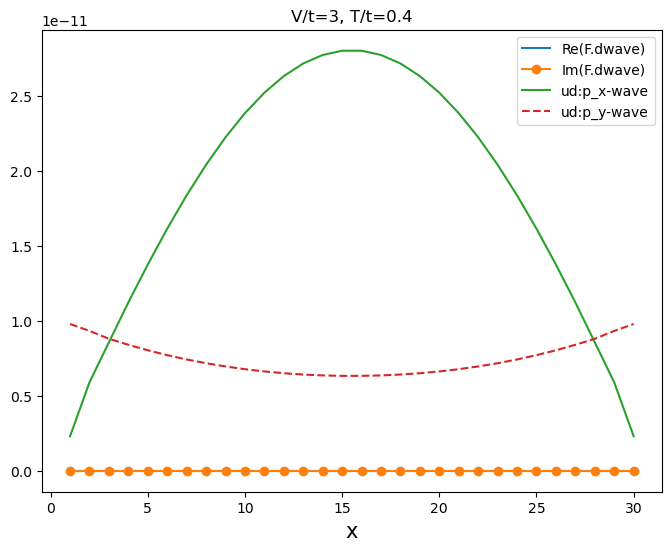

In [13]:
x = np.arange(1, width + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(Fuu.px), label="ud:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [14]:
print(F.py[X//2])
print(F.px[X//2])


(1.6108286443998007e-21-2.0164805288861522e-18j)
(-1.0712111130179835e-18-8.8347960189595e-22j)
